**AstroKit Demo: Using Galfit wrapper to do the image decomposition**
- Author: Rui Zhu
- Date: 2025-07-01
- Acknowledgements: The data used in this demo is from the [galight](https://github.com/dartoon/galight) project notebook: https://github.com/dartoon/galight_notebooks/blob/master/galight_HSC_QSO.ipynb

In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.io import fits

import astrokit as ak

dir_demo_data = ak.DIR_astrokit.parent / 'demo' / 'data'
dir_data = dir_demo_data / 'example_data_galfit'

---
# Data Check

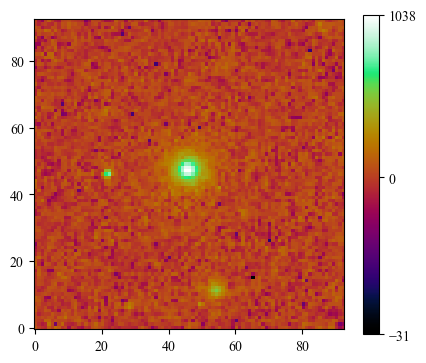

In [44]:
path_image = dir_data / 'example_from_galfit' / 'gal.fits'

hdul = fits.open(path_image)
data_img = hdul[0].data
ak.imshow(data_img)

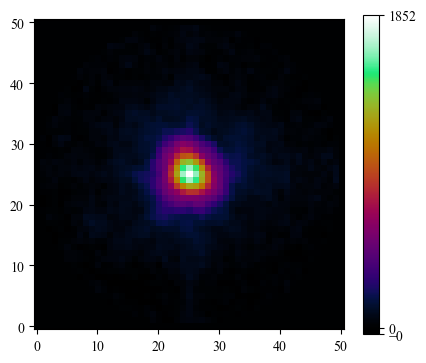

In [45]:
path_psf = dir_data / 'example_from_galfit' / 'psf.fits'

hdul = fits.open(path_psf)
data_psf = hdul[0].data
ak.imshow(data_psf)

---
# Galfit

In [46]:
galfit_models = ak.wrapper.Model(
    position=(48.5180, 51.2800), 
    mag=20.0890, 
    r_e=5.1160, 
    n_sersic=4.2490, 
    axis_ratio=0.7570,
    position_angle=-60.3690,
)

In [48]:
galfit = ak.wrapper.Galfit(
    dir_work=dir_data / 'example_from_galfit', 
    input_img_fname=path_image.name,
    output_img_fname='output.fits',

    psf_img_fname=path_psf.name,

    zeropoint=26.563, 
    pix_scale=0.038,
)

==> [astrokit.galfit] galfit settings:
    dir_work: /Users/rui/Packages/astrokit/demo/data/example_data_galfit/example_from_galfit
    ------------------------------------
    input_img_fname: gal.fits
    output_img_fname: output.fits
    sigma_img_fname: none
    mask_img_fname: none
    psf_img_fname: psf.fits
    constraints_fname: none
    ------------------------------------
    zeropoint: 26.563
    pix_scale: 0.038
    sampling_factor: 1
    fit_region: (1, 93, 1, 93)
    convbox_size: (50, 50)
    display_type: regular
    out_option: 0
    ------------------------------------


In [50]:
galfit.control_parameters()
models = [
    galfit_models.sersic(),
    galfit_models.sky()
]
galfit.make_feedme(models=models)
galfit.fit()

==> [astrokit.galfit] success: gal.fits, cost time: 0.60 s


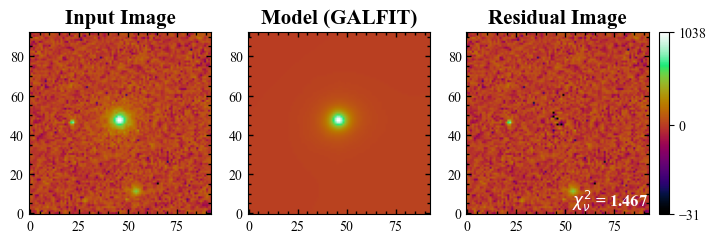

In [51]:
galfit.plot()